# SDXL Orthographic Hallucination — Baseline & Mechanistic Experiments

This notebook implements:
- **Phase 0**: Controlled prompt suite + OCR evaluation pipeline (baseline CER/WER table)
- **Exp 1**: Text-encoding bottleneck analysis (tokenization, embedding separability, denoiser sensitivity)
- **Exp 2**: Cross-attention misbinding analysis (attention hooks, ROI statistics, scene complexity ablation)

**Runtime requirement**: GPU (T4 minimum, A100 recommended for faster generation). Enable via Runtime → Change runtime type → GPU.

---
## 0. Installation & Imports

In [ ]:
from google.colab import drive
drive.flush_and_unmount()
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# # Core torch stack — matched versions
# !pip install torch==2.5.1+cu121 torchvision==0.20.1+cu121 torchaudio==2.5.1+cu121 --index-url https://download.pytorch.org/whl/cu121 --force-reinstall

# # HuggingFace stack - show output for these critical ones
# !pip install huggingface_hub==0.25.2 transformers==4.46.1 accelerate==0.34.2 diffusers==0.31.0 peft==0.14.0 --force-reinstall
# # Other dependencies
# !pip install xformers==0.0.28.post3 --index-url https://download.pytorch.org/whl/cu121 --force-reinstall
# !pip install numpy==1.26.4 surya-ocr==0.4.3 python-Levenshtein pandas matplotlib --force-reinstall



# 1. Uninstall the current conflicting versions to clear the cache
!pip uninstall -y torch torchvision torchaudio xformers

# 2. Install the 'Golden Trio' for Torch 2.5.1
!pip install torch==2.5.1+cu121 torchvision==0.20.1+cu121 torchaudio==2.5.1+cu121 --index-url https://download.pytorch.org/whl/cu121

# 3. Install xformers built specifically for Torch 2.5.1
!pip install xformers==0.0.28.post3 --index-url https://download.pytorch.org/whl/cu121

# 4. Ensure Diffusers and PEFT match this modern stack
!pip install huggingface_hub==0.25.2 transformers==4.46.1 accelerate==0.34.2 diffusers==0.31.0 peft==0.14.0

Looking in indexes: https://download.pytorch.org/whl/cu121
  Using cached https://download-r2.pytorch.org/whl/cu121/torch-2.5.1%2Bcu121-cp312-cp312-linux_x86_64.whl (780.4 MB)
  Using cached https://download-r2.pytorch.org/whl/cu121/torchvision-0.20.1%2Bcu121-cp312-cp312-linux_x86_64.whl (7.3 MB)
  Using cached https://download-r2.pytorch.org/whl/cu121/torchaudio-2.5.1%2Bcu121-cp312-cp312-linux_x86_64.whl (3.4 MB)
Looking in indexes: https://download.pytorch.org/whl/cu121
  Using cached https://download.pytorch.org/whl/cu121/xformers-0.0.28.post3-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (1.0 kB)
Using cached https://download.pytorch.org/whl/cu121/xformers-0.0.28.post3-cp312-cp312-manylinux_2_28_x86_64.whl (16.7 MB)


In [ ]:
!pip install pandas matplotlib scipy python-Levenshtein

In [ ]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from PIL import Image
from pathlib import Path
import huggingface_hub
import diffusers
from itertools import product
from collections import defaultdict
from scipy import stats
import json, os, re
from transformers import TrOCRProcessor, VisionEncoderDecoderModel

from Levenshtein import distance as levenshtein_distance

# Diffusers
from diffusers import StableDiffusionXLPipeline, DDIMScheduler
from diffusers.models.attention_processor import AttnProcessor2_0

# Transformers
from transformers import CLIPTokenizer, CLIPTextModel

# Check GPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')
if device == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Using device: cuda
GPU: NVIDIA A100-SXM4-40GB
VRAM: 42.4 GB


In [ ]:
# Output directory
# Save to Google Drive for persistence
OUTPUT_DIR = Path('/content/drive/MyDrive/sdxl_orthographic_hallucination_2 (1)')
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)
(OUTPUT_DIR / 'images').mkdir(exist_ok=True)
(OUTPUT_DIR / 'attention_maps').mkdir(exist_ok=True)
(OUTPUT_DIR / 'results').mkdir(exist_ok=True)
print('Output directories created.')

Output directories created.


---
## Phase 0: Prompt Suite & Baseline Pipeline

### 0.1 Define the Factorial Prompt Suite

In [ ]:
# ── Target strings across difficulty axes ──────────────────────────────────────
TARGET_STRINGS = {
    'short_common':    ['CAT', 'DOG', 'SUN'],
    'medium_common':   ['MARKET', 'BRIDGE', 'GARDEN'],
    'long_common':     ['STRAWBERRY', 'THUNDERBOLT', 'WATERMELON'],
    'digits':          ['2847', '90312', '15503'],
    'mixed_alphanum':  ['H2O', 'R2D2', 'B52'],
}

# Flatten to a list of (string, category) tuples
ALL_TARGETS = [
    (s, cat)
    for cat, strings in TARGET_STRINGS.items()
    for s in strings
]

# ── Scene complexity ───────────────────────────────────────────────────────────
SCENE_TEMPLATES = {
    'blank':    'a plain white sign with the word "{target}" printed clearly on it',
    'simple':   'a wooden storefront sign that clearly says "{target}"',
    'cluttered':'a neon sign on a busy city street that reads "{target}"',
}

# ── Prompt format variants ─────────────────────────────────────────────────────
# Each is a function that takes (scene_desc, target) and returns a full prompt
PROMPT_FORMATS = {
    'quoted':    lambda scene, t: scene.replace(f'"{t}"', f'"{t}"'),
    'unquoted':  lambda scene, t: scene.replace(f'"{t}"', t),
    'letterspaced': lambda scene, t: scene.replace(f'"{t}"', ' '.join(list(t))),
    'verbatim':  lambda scene, t: scene.replace(f'"{t}"', t) + f', render the exact characters: {t}',
}


# ── Seeds ──────────────────────────────────────────────────────────────────────
SEEDS = [42, 123]

# ── Build prompt grid ──────────────────────────────────────────────────────────
def build_prompt_grid(targets=ALL_TARGETS,
                      scenes=SCENE_TEMPLATES,
                      formats=PROMPT_FORMATS,
                      seeds=SEEDS):
    """
    Returns a list of dicts, each representing one generation job.
    For the full factorial design this can be large; we provide a
    `subset` flag to run a quick smoke-test first.
    """
    grid = []
    for (target, target_cat), (scene_name, scene_tmpl), (fmt_name, fmt_fn) in product(
        targets, scenes.items(), formats.items()
    ):
        scene_desc = scene_tmpl.format(target=target)
        prompt = fmt_fn(scene_desc, target)
        for seed in seeds:
            grid.append({
                'target':      target,
                'target_cat':  target_cat,
                'scene':       scene_name,
                'format':      fmt_name,
                'seed':        seed,
                'prompt':      prompt,
                'image_path':  None,  # filled in after generation
            })
    return grid


def build_smoke_test_grid():
    """Minimal grid for quick testing: 2 targets × 2 scenes × 1 format × 1 viewpoint × 2 seeds."""
    return build_prompt_grid(
        targets=[('MARKET', 'medium_common'), ('2847', 'digits')],
        scenes={k: SCENE_TEMPLATES[k] for k in ['blank', 'cluttered']},
        formats={k: PROMPT_FORMATS[k] for k in ['quoted']},
        seeds=[42, 123],
    )


# Choose which grid to run:
#   smoke_test_grid  → 8 images, fast, for debugging
#   full_grid        → ~360 images, use for real experiments - can increase if needed
SMOKE_TEST = False   # ← set to False for full run

prompt_grid = build_smoke_test_grid() if SMOKE_TEST else build_prompt_grid()
print(f'Prompt grid size: {len(prompt_grid)} generations')
pd.DataFrame(prompt_grid[:5])

Prompt grid size: 360 generations


,target,target_cat,scene,format,seed,prompt,image_path
0,CAT,short_common,blank,quoted,42,"a plain white sign with the word ""CAT"" printed...",None
1,CAT,short_common,blank,quoted,123,"a plain white sign with the word ""CAT"" printed...",None
2,CAT,short_common,blank,unquoted,42,a plain white sign with the word CAT printed c...,None
3,CAT,short_common,blank,unquoted,123,a plain white sign with the word CAT printed c...,None
4,CAT,short_common,blank,letterspaced,42,a plain white sign with the word C A T printed...,None


### 0.2 Load SDXL

In [ ]:
# Load SDXL base model
# fp16 + xformers keeps VRAM under 12 GB on T4
MODEL_ID = 'stabilityai/stable-diffusion-xl-base-1.0'

pipe = StableDiffusionXLPipeline.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    variant='fp16',
    use_safetensors=True,
)
pipe.scheduler = DDIMScheduler.from_config(pipe.scheduler.config)
pipe = pipe.to(device)

# Enable memory-efficient attention if xformers is available
try:
    pipe.enable_xformers_memory_efficient_attention()
    print('xformers enabled')
except Exception:
    print('xformers not available, using default attention')

# Fixed generation settings — never change these across experiments
GEN_KWARGS = dict(
    height=1024,
    width=1024,
    num_inference_steps=50,
    guidance_scale=7.5,
    negative_prompt='blurry, low quality, distorted',
)

print('SDXL loaded.')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_token.py:90: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

xformers enabled
SDXL loaded.


### 0.3 Generate Images

In [ ]:
def generate_image(pipe, prompt, seed, save_path=None):
    """Generate a single image with a fixed seed and save it."""
    generator = torch.Generator(device=device).manual_seed(seed)
    with torch.inference_mode():
        result = pipe(prompt=prompt, generator=generator, **GEN_KWARGS)
    image = result.images[0]
    if save_path:
        image.save(save_path)
    return image


# Run generation over the prompt grid
# Skips already-generated images so you can resume interrupted runs
for i, entry in enumerate(prompt_grid):
    fname = f"{entry['target']}_{entry['scene']}_{entry['format']}_seed{entry['seed']}.png"
    save_path = OUTPUT_DIR / 'images' / fname
    entry['image_path'] = str(save_path)

    if save_path.exists():
        print(f'[{i+1}/{len(prompt_grid)}] Skipping (exists): {fname}')
        continue

    print(f'[{i+1}/{len(prompt_grid)}] Generating: {fname}')
    generate_image(pipe, entry['prompt'], entry['seed'], save_path=save_path)

print('\nAll generations complete.')

[1/360] Skipping (exists): CAT_blank_quoted_seed42.png
[2/360] Skipping (exists): CAT_blank_quoted_seed123.png
[3/360] Skipping (exists): CAT_blank_unquoted_seed42.png
[4/360] Skipping (exists): CAT_blank_unquoted_seed123.png
[5/360] Skipping (exists): CAT_blank_letterspaced_seed42.png
[6/360] Skipping (exists): CAT_blank_letterspaced_seed123.png
[7/360] Skipping (exists): CAT_blank_verbatim_seed42.png
[8/360] Skipping (exists): CAT_blank_verbatim_seed123.png
[9/360] Skipping (exists): CAT_simple_quoted_seed42.png
[10/360] Skipping (exists): CAT_simple_quoted_seed123.png
[11/360] Skipping (exists): CAT_simple_unquoted_seed42.png
[12/360] Skipping (exists): CAT_simple_unquoted_seed123.png
[13/360] Skipping (exists): CAT_simple_letterspaced_seed42.png
[14/360] Skipping (exists): CAT_simple_letterspaced_seed123.png
[15/360] Skipping (exists): CAT_simple_verbatim_seed42.png
[16/360] Skipping (exists): CAT_simple_verbatim_seed123.png
[17/360] Skipping (exists): CAT_cluttered_quoted_seed42.p

### 0.4 OCR Evaluation Pipeline

In [ ]:
# trocr_processor = TrOCRProcessor.from_pretrained('microsoft/trocr-base-printed')
# trocr_model = VisionEncoderDecoderModel.from_pretrained('microsoft/trocr-base-printed').to(device)
# trocr_model.eval()
# print('TrOCR ready.')

# def run_ocr(image_path):
#     """
#     Returns list of (bbox, text, confidence) tuples
#     """
#     image = Image.open(image_path).convert('RGB')
#     pixel_values = trocr_processor(image, return_tensors='pt').pixel_values.to(device)
#     with torch.no_grad():
#         generated_ids = trocr_model.generate(pixel_values)
#     text = trocr_processor.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()
#     if not text:
#         return []
#     # Return in same (bbox, text, confidence) format score_image expects
#     return [([[0,0],[0,0],[0,0],[0,0]], text, 1.0)]


In [ ]:
!pip install easyocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 39.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 31.8 MB/s eta 0:00:00


In [ ]:
import easyocr

ocr_reader = easyocr.Reader(['en'], gpu=True)
print('EasyOCR ready.')

def run_ocr(image_path):
    # detail=1 returns (bbox, text, confidence) — already the format score_image expects
    results = ocr_reader.readtext(str(image_path), detail=1)
    return results if results else []

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% CompleteEasyOCR ready.


In [ ]:
# ── Metric functions ───────────────────────────────────────────────────────────

def ned(detected, target):
    """Normalized Edit Distance ∈ [0, 1]. 0 = perfect match."""
    if len(detected) == 0 and len(target) == 0:
        return 0.0
    return levenshtein_distance(detected.upper(), target.upper()) / max(len(detected), len(target))


def cer(detected, target):
    """Character Error Rate = edit_distance / len(target). Can exceed 1."""
    if len(target) == 0:
        return 0.0 if len(detected) == 0 else 1.0
    return levenshtein_distance(detected.upper(), target.upper()) / len(target)


def wer(detected, target):
    """Word Error Rate at word level."""
    d_words = detected.upper().split()
    t_words = target.upper().split()
    if len(t_words) == 0:
        return 0.0 if len(d_words) == 0 else 1.0
    return levenshtein_distance(d_words, t_words) / len(t_words)


def classify_failure(detected, target, ned_score):
    """Classify the type of orthographic hallucination."""
    if detected == '':
        return 'no_text'
    if ned_score == 0.0:
        return 'success'
    if ned_score <= 0.1:
        return 'near_miss'
    # Check for visually similar glyph substitutions
    glyph_subs = {'O': '0', '0': 'O', 'I': '1', '1': 'I', 'E': '3', 'S': '5', 'B': '8'}
    cleaned = detected.upper()
    for orig, sub in glyph_subs.items():
        cleaned = cleaned.replace(sub, orig)
    if ned(cleaned, target) <= 0.1:
        return 'glyph_substitution'
    if ned_score > 0.8:
        return 'garbled'
    return 'partial'



# ── Per-image OCR scoring ──────────────────────────────────────────────────────

def score_image(image_path, target, confidence_threshold=0.3):
    """
    Run OCR on an image and return a dict of metrics.
    Handles no-detection and multi-detection cases.
    """
    results = run_ocr(image_path)

    if not results:
        return {
            'detected_string': '',
            'ocr_confidence':  0.0,
            'ned':             1.0,
            'cer':             1.0,
            'wer':             1.0,
            'success_strict':  False,
            'success_lenient': False,
            'failure_type':    'no_text',
            'n_detections':    0,
            'spurious_text':   False,
        }

    # Sort detections top-to-bottom, left-to-right
    results_sorted = sorted(results, key=lambda r: (r[0][0][1], r[0][0][0]))

    # Among all detections, find the one with best NED against target
    best_ned = 1.0
    best_str = ''
    best_conf = 0.0

    # Also try concatenating all detections
    concat_str = ''.join(r[1] for r in results_sorted if r[2] >= confidence_threshold)

    candidates = [(r[1], r[2]) for r in results_sorted] + [(concat_str, np.mean([r[2] for r in results_sorted]))]

    for cand_str, cand_conf in candidates:
        n = ned(cand_str, target)
        if n < best_ned:
            best_ned = n
            best_str = cand_str
            best_conf = cand_conf

    # Spurious text: any high-confidence detection that doesn't match target
    spurious = any(
        r[2] >= confidence_threshold and ned(r[1], target) > 0.5
        for r in results_sorted
    )

    ned_score = best_ned
    return {
        'detected_string': best_str,
        'ocr_confidence':  float(best_conf),
        'ned':             float(ned_score),
        'cer':             float(cer(best_str, target)),
        'wer':             float(wer(best_str, target)),
        'success_strict':  best_str.upper().strip() == target.upper().strip(),
        'success_lenient': ned_score <= 0.1,
        'failure_type':    classify_failure(best_str, target, ned_score),
        'n_detections':    len(results),
        'spurious_text':   spurious,
    }


print('Metric functions defined.')

Metric functions defined.


In [ ]:
!pip install gdown -q
!gdown --folder https://drive.google.com/drive/folders/1gJetCGMfFuzJMIBsfW2PdNTWHQmezumL \
    -O /content/sdxl_data/ --remaining-ok

Retrieving folder contents
Retrieving folder 15FAPwzOjvtEBCLdTSw-vr_FMpyNVdiy8 attention_maps
Retrieving folder 1sCW5mRlTc2tM4_dVfckkwdFSTg12Ro_D images
Processing file 1Vea5mmAXzpBSh-Rp8-QmQ4NioXepu3GU 2847_blank_letterspaced_seed42.png
Processing file 18et8yV-Vg3zqFqN6zH47YJqZ-QY3aNLb 2847_blank_letterspaced_seed123.png
Processing file 1gAJQKQiCtjB_Xndhgz_DEtpwF1chXMWx 2847_blank_quoted_seed42.png
Processing file 1A5ozDnmY7hBxBUmFjfvAgBI9l96v51D9 2847_blank_quoted_seed123.png
Processing file 1cRzFRrnqmhGnjeHyL0Q_QAi-zZBIIbRI 2847_blank_unquoted_seed42.png
Processing file 1uCwIag_xc9w-DiN-oGrjhSKHqHQidMtg 2847_blank_unquoted_seed123.png
Processing file 10Saz3RihYNMM4Qr7q6VEJmobKI4SESi- 2847_blank_verbatim_seed42.png
Processing file 1mwNqoMq5-5fSGMneOmcL3O9WahDaeYHR 2847_blank_verbatim_seed123.png
Processing file 1T10JjLIqrLeFQiLm0sgJWKP8MKUJ9XjO 2847_cluttered_letterspaced_seed42.png
Processing file 1Lhb5VSqdbl1a44_59YquIh2XMKIzoVKQ 2847_cluttered_letterspaced_seed123.png
Processing f

In [ ]:
OUTPUT_DIR = Path("/content/drive/MyDrive/sdxl_orthographic_hallucination_2 (1)")

images = list(OUTPUT_DIR.rglob('*.png'))
print(f"Found {len(images)} images")
print(images[:3])

(OUTPUT_DIR / 'results').mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / 'images').mkdir(parents=True, exist_ok=True)

Found 360 images
[PosixPath('/content/drive/MyDrive/sdxl_orthographic_hallucination_2 (1)/images/2847_blank_letterspaced_seed123.png'), PosixPath('/content/drive/MyDrive/sdxl_orthographic_hallucination_2 (1)/images/WATERMELON_blank_verbatim_seed42.png'), PosixPath('/content/drive/MyDrive/sdxl_orthographic_hallucination_2 (1)/images/MARKET_simple_verbatim_seed42.png')]


In [ ]:
# to avoid regeneration
prompt_grid = build_prompt_grid()  # swap for build_prompt_grid() for full grid

for entry in prompt_grid:
    fname = f"{entry['target']}_{entry['scene']}_{entry['format']}_seed{entry['seed']}.png"
    matches = list(OUTPUT_DIR.rglob(fname))
    entry['image_path'] = str(matches[0]) if matches else None

found = sum(1 for e in prompt_grid if e['image_path'] is not None)
print(f"{found}/{len(prompt_grid)} images matched")


360/360 images matched


In [ ]:
# Select the first 5 entries from prompt_grid for a quick test
test_grid_subset = prompt_grid[:5]
test_results_records = []

print(f"Running OCR evaluation on {len(test_grid_subset)} images:")

for i, entry in enumerate(test_grid_subset):
    # image_path should already be populated from the previous generation step (cell JFg1GA2GVico)
    if entry.get('image_path') is None or not Path(entry['image_path']).exists():
        print(f"  Warning: Image not found for {entry['target']} (seed {entry['seed']}). It might not have been generated yet or path is incorrect. Skipping evaluation for this entry.")
        continue

    # Extract filename for printing
    fname = Path(entry['image_path']).name
    print(f"[{i+1}/{len(test_grid_subset)}] Evaluating: {fname}")

    scores = score_image(entry['image_path'], entry['target'])
    record = {**entry, **scores}
    test_results_records.append(record)

    print(f"  Target: {entry['target']:<10} Detected: '{scores['detected_string']:<15}' CER: {scores['cer']:.2f} Type: {scores['failure_type']}")

print("\n--- Test Results ---")
if test_results_records:
    test_df = pd.DataFrame(test_results_records)
    # Display relevant columns, dropping 'prompt' as it can be very long
    display_cols = ['target', 'scene', 'format', 'detected_string', 'cer', 'failure_type', 'success_lenient']
    print(test_df[display_cols].to_string())

    # Optionally save this test subset results
    test_df.to_csv(OUTPUT_DIR / 'results' / 'test_subset_scores_quick.csv', index=False)
    print(f"\nTest subset results saved to: {OUTPUT_DIR / 'results' / 'test_subset_scores_quick.csv'}")
else:
    print("No images were evaluated. Please ensure images have been generated by running the previous cell.")

Running OCR evaluation on 5 images:
[1/5] Evaluating: CAT_blank_quoted_seed42.png
  Target: CAT        Detected: 'CAXTI          ' CER: 0.67 Type: partial
[2/5] Evaluating: CAT_blank_quoted_seed123.png
  Target: CAT        Detected: 'CAIT           ' CER: 0.33 Type: partial
[3/5] Evaluating: CAT_blank_unquoted_seed42.png
  Target: CAT        Detected: 'Cd             ' CER: 0.67 Type: partial
[4/5] Evaluating: CAT_blank_unquoted_seed123.png
  Target: CAT        Detected: 'CATAT          ' CER: 0.67 Type: partial
[5/5] Evaluating: CAT_blank_letterspaced_seed42.png
  Target: CAT        Detected: 'CAT            ' CER: 0.00 Type: success

--- Test Results ---
  target  scene        format detected_string       cer failure_type  success_lenient
0    CAT  blank        quoted           CAXTI  0.666667      partial            False
1    CAT  blank        quoted            CAIT  0.333333      partial            False
2    CAT  blank      unquoted              Cd  0.666667      partial         

In [ ]:
# Run OCR evaluation over all generated images
results_records = []

for i, entry in enumerate(prompt_grid):
    if entry['image_path'] is None or not Path(entry['image_path']).exists():
        print(f'[{i+1}] Missing image, skipping: {entry}')
        continue

    scores = score_image(entry['image_path'], entry['target'])
    record = {**entry, **scores}
    results_records.append(record)

    print(f"[{i+1}/{len(prompt_grid)}] {entry['target']:15s} "
          f"scene={entry['scene']:10s} fmt={entry['format']:12s} "
          f"detected='{scores['detected_string']:15s}' "
          f"CER={scores['cer']:.2f} type={scores['failure_type']}")

# Save results
results_df = pd.DataFrame(results_records)
results_df.to_csv(OUTPUT_DIR / 'results' / 'baseline_scores.csv', index=False)
print(f'\nResults saved. Shape: {results_df.shape}')

[1/360] CAT             scene=blank      fmt=quoted       detected='CAXTI          ' CER=0.67 type=partial
[2/360] CAT             scene=blank      fmt=quoted       detected='CAIT           ' CER=0.33 type=partial
[3/360] CAT             scene=blank      fmt=unquoted     detected='Cd             ' CER=0.67 type=partial
[4/360] CAT             scene=blank      fmt=unquoted     detected='CATAT          ' CER=0.67 type=partial
[5/360] CAT             scene=blank      fmt=letterspaced detected='CAT            ' CER=0.00 type=success
[6/360] CAT             scene=blank      fmt=letterspaced detected='AT             ' CER=0.33 type=partial
[7/360] CAT             scene=blank      fmt=verbatim     detected='Cat            ' CER=0.00 type=success
[8/360] CAT             scene=blank      fmt=verbatim     detected='Caz            ' CER=0.33 type=partial
[9/360] CAT             scene=simple     fmt=quoted       detected='C ATT          ' CER=0.67 type=partial
[10/360] CAT             scene=simple

### 0.5 Baseline Visualization

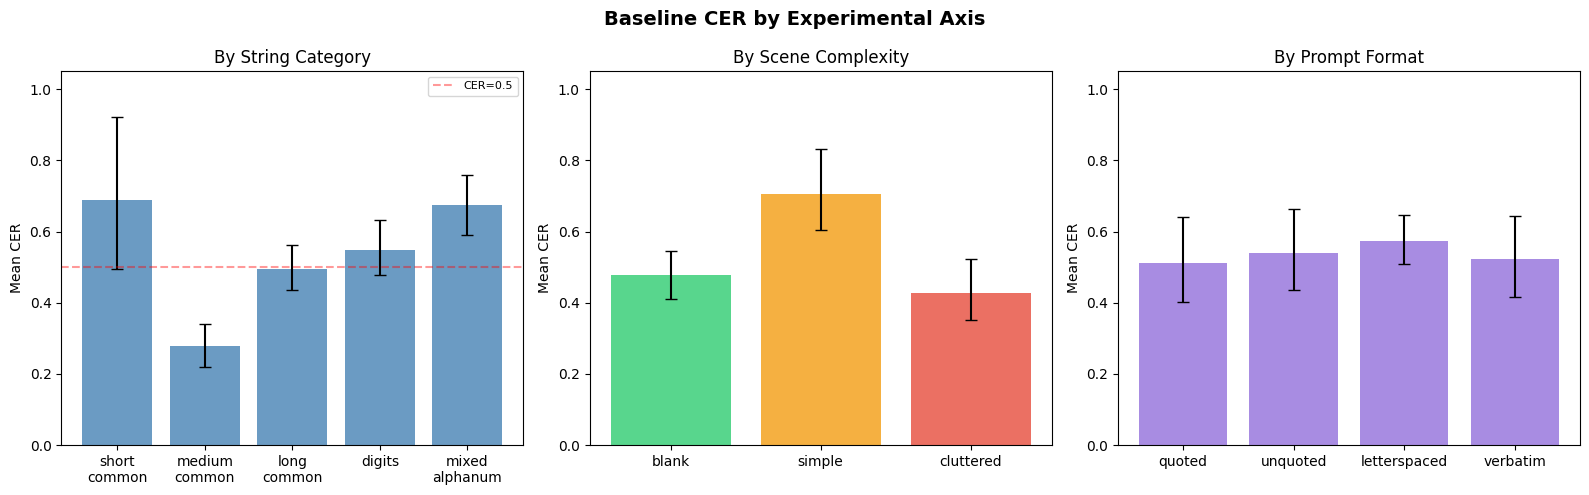

Baseline plots saved.


In [ ]:
def bootstrap_ci(values, n_boot=1000, ci=95):
    """Return (mean, lower_ci, upper_ci) via bootstrapping."""
    values = np.array(values)
    boot_means = [np.mean(np.random.choice(values, size=len(values), replace=True)) for _ in range(n_boot)]
    lo = np.percentile(boot_means, (100 - ci) / 2)
    hi = np.percentile(boot_means, 100 - (100 - ci) / 2)
    return np.mean(values), lo, hi


fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Baseline CER by Experimental Axis', fontsize=14, fontweight='bold')

# ── Plot 1: CER by target category ────────────────────────────────────────────
ax = axes[0]
cat_order = ['short_common', 'medium_common', 'long_common', 'digits', 'mixed_alphanum']
cat_stats = []
for cat in cat_order:
    subset = results_df[results_df['target_cat'] == cat]['cer'].values
    if len(subset) > 0:
        mean, lo, hi = bootstrap_ci(subset)
        cat_stats.append({'cat': cat.replace('_', '\n'), 'mean': mean, 'lo': lo, 'hi': hi})

cat_df = pd.DataFrame(cat_stats)
bars = ax.bar(cat_df['cat'], cat_df['mean'], color='steelblue', alpha=0.8)
ax.errorbar(range(len(cat_df)), cat_df['mean'],
            yerr=[cat_df['mean'] - cat_df['lo'], cat_df['hi'] - cat_df['mean']],
            fmt='none', color='black', capsize=4)
ax.set_ylabel('Mean CER')
ax.set_title('By String Category')
ax.set_ylim(0, 1.05)
ax.axhline(0.5, color='red', linestyle='--', alpha=0.4, label='CER=0.5')
ax.legend(fontsize=8)

# ── Plot 2: CER by scene complexity ───────────────────────────────────────────
ax = axes[1]
scene_stats = []
for scene in ['blank', 'simple', 'cluttered']:
    subset = results_df[results_df['scene'] == scene]['cer'].values
    if len(subset) > 0:
        mean, lo, hi = bootstrap_ci(subset)
        scene_stats.append({'scene': scene, 'mean': mean, 'lo': lo, 'hi': hi})

scene_df = pd.DataFrame(scene_stats)
colors = ['#2ecc71', '#f39c12', '#e74c3c']
ax.bar(scene_df['scene'], scene_df['mean'], color=colors, alpha=0.8)
ax.errorbar(range(len(scene_df)), scene_df['mean'],
            yerr=[scene_df['mean'] - scene_df['lo'], scene_df['hi'] - scene_df['mean']],
            fmt='none', color='black', capsize=4)
ax.set_ylabel('Mean CER')
ax.set_title('By Scene Complexity')
ax.set_ylim(0, 1.05)

# ── Plot 3: CER by prompt format ──────────────────────────────────────────────
ax = axes[2]
fmt_stats = []
for fmt in ['quoted', 'unquoted', 'letterspaced', 'verbatim']:
    subset = results_df[results_df['format'] == fmt]['cer'].values
    if len(subset) > 0:
        mean, lo, hi = bootstrap_ci(subset)
        fmt_stats.append({'fmt': fmt, 'mean': mean, 'lo': lo, 'hi': hi})

fmt_df = pd.DataFrame(fmt_stats)
ax.bar(fmt_df['fmt'], fmt_df['mean'], color='mediumpurple', alpha=0.8)
ax.errorbar(range(len(fmt_df)), fmt_df['mean'],
            yerr=[fmt_df['mean'] - fmt_df['lo'], fmt_df['hi'] - fmt_df['mean']],
            fmt='none', color='black', capsize=4)
ax.set_ylabel('Mean CER')
ax.set_title('By Prompt Format')
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'results' / 'baseline_cer_by_axis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Baseline plots saved.')

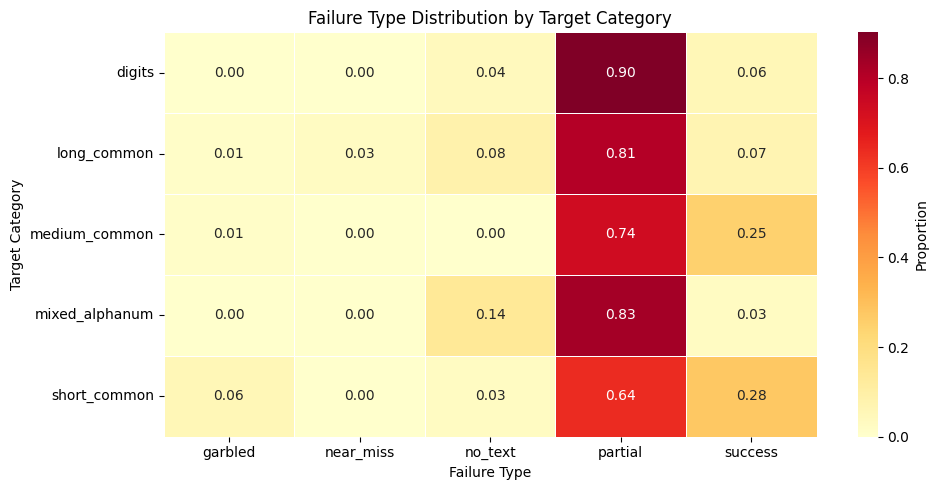

In [ ]:
# Failure type distribution heatmap: rows=target_cat, cols=failure_type
failure_pivot = (
    results_df.groupby(['target_cat', 'failure_type'])
    .size()
    .unstack(fill_value=0)
)
# Normalize to proportions per row
failure_pivot_pct = failure_pivot.div(failure_pivot.sum(axis=1), axis=0)

plt.figure(figsize=(10, 5))
sns.heatmap(failure_pivot_pct, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Proportion'})
plt.title('Failure Type Distribution by Target Category')
plt.ylabel('Target Category')
plt.xlabel('Failure Type')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'results' / 'failure_type_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# 1. Text Encoding Bottleneck

### 1.1 Tokenization analysis

In [ ]:
tokenizer_1 = pipe.tokenizer      # CLIP ViT-L
tokenizer_2 = pipe.tokenizer_2    # OpenCLIP ViT-bigG

target_cer = results_df.groupby('target').agg(
    mean_cer=('cer', 'mean'),
    n_samples=('cer', 'count'),
    target_cat=('target_cat', 'first')
).reset_index()

print(f"Unique targets: {len(target_cer)}")
print(target_cer[['target', 'target_cat', 'mean_cer', 'n_samples']].to_string())

Unique targets: 15
         target      target_cat  mean_cer  n_samples
0         15503          digits  0.466667         24
1          2847          digits  0.510417         24
2         90312          digits  0.666667         24
3           B52  mixed_alphanum  0.486111         24
4        BRIDGE   medium_common  0.340278         24
5           CAT    short_common  0.583333         24
6           DOG    short_common  0.916667         24
7        GARDEN   medium_common  0.180556         24
8           H2O  mixed_alphanum  0.638889         24
9        MARKET   medium_common  0.312500         24
10         R2D2  mixed_alphanum  0.895833         24
11   STRAWBERRY     long_common  0.391667         24
12          SUN    short_common  0.569444         24
13  THUNDERBOLT     long_common  0.583333         24
14   WATERMELON     long_common  0.512500         24


In [ ]:
frag_records = []

for _, row in target_cer.iterrows():
    target = row['target']
    n_chars = len(target)

    tok1 = tokenizer_1.encode(target)
    tok2 = tokenizer_2.encode(target)

    content_tok1 = [t for t in tok1 if t not in tokenizer_1.all_special_ids]
    content_tok2 = [t for t in tok2 if t not in tokenizer_2.all_special_ids]

    n_tok1 = len(content_tok1)
    n_tok2 = len(content_tok2)

    frag_records.append({
        'target': target,
        'target_cat': row['target_cat'],
        'n_chars': n_chars,
        'n_tokens_clip': n_tok1,
        'n_tokens_openclip': n_tok2,
        'frag_clip': n_tok1 / n_chars,
        'frag_openclip': n_tok2 / n_chars,
        'frag_mean': (n_tok1 + n_tok2) / (2 * n_chars),
        'mean_cer': row['mean_cer'],
        'subtokens_clip': tokenizer_1.convert_ids_to_tokens(content_tok1),
        'subtokens_openclip': tokenizer_2.convert_ids_to_tokens(content_tok2),
    })

frag_df = pd.DataFrame(frag_records)

for _, row in frag_df.iterrows():
    print(f"\n{row['target']!r} ({row['n_chars']} chars, CER={row['mean_cer']:.3f})")
    print(f"  CLIP:     {row['subtokens_clip']}")
    print(f"  OpenCLIP: {row['subtokens_openclip']}")
    print(f"  Frag: {row['frag_clip']:.3f} / {row['frag_openclip']:.3f}")


'15503' (5 chars, CER=0.467)
  CLIP:     ['1</w>', '5</w>', '5</w>', '0</w>', '3</w>']
  OpenCLIP: ['1</w>', '5</w>', '5</w>', '0</w>', '3</w>']
  Frag: 1.000 / 1.000

'2847' (4 chars, CER=0.510)
  CLIP:     ['2</w>', '8</w>', '4</w>', '7</w>']
  OpenCLIP: ['2</w>', '8</w>', '4</w>', '7</w>']
  Frag: 1.000 / 1.000

'90312' (5 chars, CER=0.667)
  CLIP:     ['9</w>', '0</w>', '3</w>', '1</w>', '2</w>']
  OpenCLIP: ['9</w>', '0</w>', '3</w>', '1</w>', '2</w>']
  Frag: 1.000 / 1.000

'B52' (3 chars, CER=0.486)
  CLIP:     ['b</w>', '5</w>', '2</w>']
  OpenCLIP: ['b</w>', '5</w>', '2</w>']
  Frag: 1.000 / 1.000

'BRIDGE' (6 chars, CER=0.340)
  CLIP:     ['bridge</w>']
  OpenCLIP: ['bridge</w>']
  Frag: 0.167 / 0.167

'CAT' (3 chars, CER=0.583)
  CLIP:     ['cat</w>']
  OpenCLIP: ['cat</w>']
  Frag: 0.333 / 0.333

'DOG' (3 chars, CER=0.917)
  CLIP:     ['dog</w>']
  OpenCLIP: ['dog</w>']
  Frag: 0.333 / 0.333

'GARDEN' (6 chars, CER=0.181)
  CLIP:     ['garden</w>']
  OpenCLIP: ['garden</w>

Pearson  r=0.3939  p=0.1463
Spearman rho=0.3687  p=0.1763


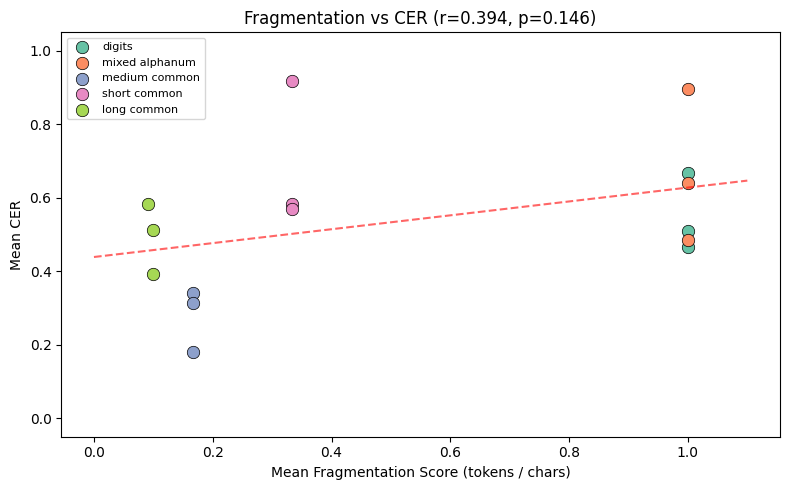

In [ ]:
r, p = stats.pearsonr(frag_df['frag_mean'], frag_df['mean_cer'])
rho, p_s = stats.spearmanr(frag_df['frag_mean'], frag_df['mean_cer'])
print(f"Pearson  r={r:.4f}  p={p:.4f}")
print(f"Spearman rho={rho:.4f}  p={p_s:.4f}")

fig, ax = plt.subplots(figsize=(8, 5))

cats = frag_df['target_cat'].unique()
colors = {c: plt.cm.Set2(i) for i, c in enumerate(cats)}

for cat in cats:
    mask = frag_df['target_cat'] == cat
    ax.scatter(frag_df.loc[mask, 'frag_mean'], frag_df.loc[mask, 'mean_cer'],
               c=[colors[cat]], label=cat.replace('_', ' '), s=80,
               edgecolors='black', linewidth=0.5)

slope, intercept = np.polyfit(frag_df['frag_mean'], frag_df['mean_cer'], 1)
x_line = np.linspace(0, 1.1, 100)
ax.plot(x_line, slope * x_line + intercept, 'r--', alpha=0.6)

ax.set_xlabel('Mean Fragmentation Score (tokens / chars)')
ax.set_ylabel('Mean CER')
ax.set_title(f'Fragmentation vs CER (r={r:.3f}, p={p:.3f})')
ax.legend(fontsize=8)
ax.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'results' / 'exp1_1_fragmentation_vs_cer.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.2 Embedding separability

In [ ]:
def get_embedding(text, tokenizer, encoder):
    """Get pooled text embedding for a string."""
    tokens = tokenizer(text, return_tensors="pt", padding=True, truncation=True)
    tokens = {k: v.to(encoder.device) for k, v in tokens.items()}
    with torch.no_grad():
        out = encoder(**tokens)
    # Use last hidden state, mean-pooled
    return out.last_hidden_state.mean(dim=1).squeeze().cpu().float()

def make_neighbors(target):
    """Generate minimal-edit neighbors: substitutions, insertions, deletions."""
    neighbors = []
    chars = 'ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789'

    # Substitutions: swap each character for something else
    for i in range(len(target)):
        for c in chars:
            if c != target[i]:
                new = target[:i] + c + target[i+1:]
                neighbors.append(('sub', i, new))
                break  # just one substitution per position

    # Deletions: remove each character
    for i in range(len(target)):
        new = target[:i] + target[i+1:]
        neighbors.append(('del', i, new))

    # Insertions: add a character at each position
    for i in range(len(target) + 1):
        new = target[:i] + 'X' + target[i:]
        neighbors.append(('ins', i, new))

    return neighbors

In [ ]:
import torch.nn.functional as F

# Get text encoders
text_encoder_1 = pipe.text_encoder    # CLIP ViT-L
text_encoder_2 = pipe.text_encoder_2  # OpenCLIP ViT-bigG

# Compute embeddings and distances
sep_records = []

for target in target_cer['target'].values:
    neighbors = make_neighbors(target)

    emb1_target = get_embedding(target, tokenizer_1, text_encoder_1)
    emb2_target = get_embedding(target, tokenizer_2, text_encoder_2)

    for edit_type, pos, neighbor in neighbors:
        emb1_neighbor = get_embedding(neighbor, tokenizer_1, text_encoder_1)
        emb2_neighbor = get_embedding(neighbor, tokenizer_2, text_encoder_2)

        cos1 = F.cosine_similarity(emb1_target.unsqueeze(0), emb1_neighbor.unsqueeze(0)).item()
        cos2 = F.cosine_similarity(emb2_target.unsqueeze(0), emb2_neighbor.unsqueeze(0)).item()

        sep_records.append({
            'target': target,
            'neighbor': neighbor,
            'edit_type': edit_type,
            'edit_pos': pos,
            'cos_clip': cos1,
            'cos_openclip': cos2,
            'cos_mean': (cos1 + cos2) / 2,
            'dist_clip': 1 - cos1,
            'dist_openclip': 1 - cos2,
        })

sep_df = pd.DataFrame(sep_records)
print(f"Computed {len(sep_df)} pairwise distances across {len(target_cer)} targets")

Computed 261 pairwise distances across 15 targets


In [ ]:
# Summary stats per target
sep_summary = sep_df.groupby('target').agg(
    mean_cos_clip=('cos_clip', 'mean'),
    mean_cos_openclip=('cos_openclip', 'mean'),
    mean_cos=('cos_mean', 'mean'),
).reset_index()

sep_summary = sep_summary.merge(target_cer[['target', 'mean_cer', 'target_cat']], on='target')

print("Mean cosine similarity between target and its 1-edit neighbors:")
print(sep_summary[['target', 'target_cat', 'mean_cos_clip', 'mean_cos_openclip', 'mean_cer']].to_string())

# Correlation: high similarity (hard to distinguish) -> high CER?
r, p = stats.pearsonr(sep_summary['mean_cos'], sep_summary['mean_cer'])
rho, p_s = stats.spearmanr(sep_summary['mean_cos'], sep_summary['mean_cer'])
print(f"\nPearson  r={r:.4f}  p={p:.4f}")
print(f"Spearman rho={rho:.4f}  p={p_s:.4f}")

Mean cosine similarity between target and its 1-edit neighbors:
         target      target_cat  mean_cos_clip  mean_cos_openclip  mean_cer
0         15503          digits       0.807985           0.892846  0.466667
1          2847          digits       0.804647           0.865892  0.510417
2         90312          digits       0.820062           0.895294  0.666667
3           B52  mixed_alphanum       0.717431           0.841179  0.486111
4        BRIDGE   medium_common       0.709686           0.726622  0.340278
5           CAT    short_common       0.691981           0.708820  0.583333
6           DOG    short_common       0.716785           0.707184  0.916667
7        GARDEN   medium_common       0.636413           0.738348  0.180556
8           H2O  mixed_alphanum       0.714035           0.825100  0.638889
9        MARKET   medium_common       0.654827           0.758714  0.312500
10         R2D2  mixed_alphanum       0.735920           0.847180  0.895833
11   STRAWBERRY     long

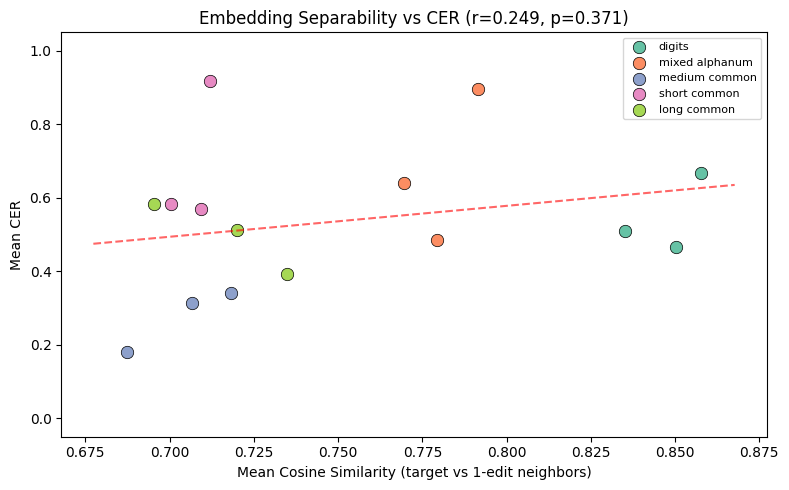

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

cats = sep_summary['target_cat'].unique()
colors = {c: plt.cm.Set2(i) for i, c in enumerate(cats)}

for cat in cats:
    mask = sep_summary['target_cat'] == cat
    ax.scatter(sep_summary.loc[mask, 'mean_cos'], sep_summary.loc[mask, 'mean_cer'],
               c=[colors[cat]], label=cat.replace('_', ' '), s=80,
               edgecolors='black', linewidth=0.5)

slope, intercept = np.polyfit(sep_summary['mean_cos'], sep_summary['mean_cer'], 1)
x_line = np.linspace(sep_summary['mean_cos'].min() - 0.01, sep_summary['mean_cos'].max() + 0.01, 100)
ax.plot(x_line, slope * x_line + intercept, 'r--', alpha=0.6)

ax.set_xlabel('Mean Cosine Similarity (target vs 1-edit neighbors)')
ax.set_ylabel('Mean CER')
ax.set_title(f'Embedding Separability vs CER (r={r:.3f}, p={p:.3f})')
ax.legend(fontsize=8)
ax.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'results' / 'exp1_2_separability_vs_cer.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.3 Denoiser sensitivity

In [ ]:
def get_noise_pred(pipe, prompt, seed, timestep_idx=25):
    """
    Run SDXL up to a specific timestep and return the predicted noise.
    timestep_idx: which step to capture (0=first, 49=last for 50 steps)
    """
    g = torch.Generator(device='cpu').manual_seed(seed)
    latents = pipe.prepare_latents(
        1, pipe.unet.config.in_channels, 1024, 1024,
        torch.float16, pipe.device, generator=g
    )

    pipe.scheduler.set_timesteps(50, device=pipe.device)
    timesteps = pipe.scheduler.timesteps

    # Encode prompt
    prompt_embeds, negative_embeds, pooled_prompt_embeds, negative_pooled = pipe.encode_prompt(
        prompt=prompt,
        device=pipe.device,
        num_images_per_prompt=1,
        do_classifier_free_guidance=True,
        negative_prompt='blurry, low quality, distorted',
    )

    add_text_embeds = pooled_prompt_embeds
    add_time_ids = pipe._get_add_time_ids(
        (1024, 1024), (0, 0), (1024, 1024),
        dtype=prompt_embeds.dtype,
        text_encoder_projection_dim=pipe.text_encoder_2.config.projection_dim,
    )
    add_time_ids = add_time_ids.to(pipe.device)

    # Denoise up to target timestep
    for i, t in enumerate(timesteps):
        if i > timestep_idx:
            break

        latent_input = torch.cat([latents] * 2)
        latent_input = pipe.scheduler.scale_model_input(latent_input, t)

        added_cond = {
            "text_embeds": torch.cat([negative_pooled, add_text_embeds]),
            "time_ids": torch.cat([add_time_ids] * 2),
        }

        with torch.no_grad():
            noise_pred = pipe.unet(
                latent_input, t,
                encoder_hidden_states=torch.cat([negative_embeds, prompt_embeds]),
                added_cond_kwargs=added_cond,
            ).sample

        # CFG
        noise_uncond, noise_text = noise_pred.chunk(2)
        noise_pred = noise_uncond + 7.5 * (noise_text - noise_uncond)

        latents = pipe.scheduler.step(noise_pred, t, latents).prev_sample

    return noise_pred.detach().cpu().float()

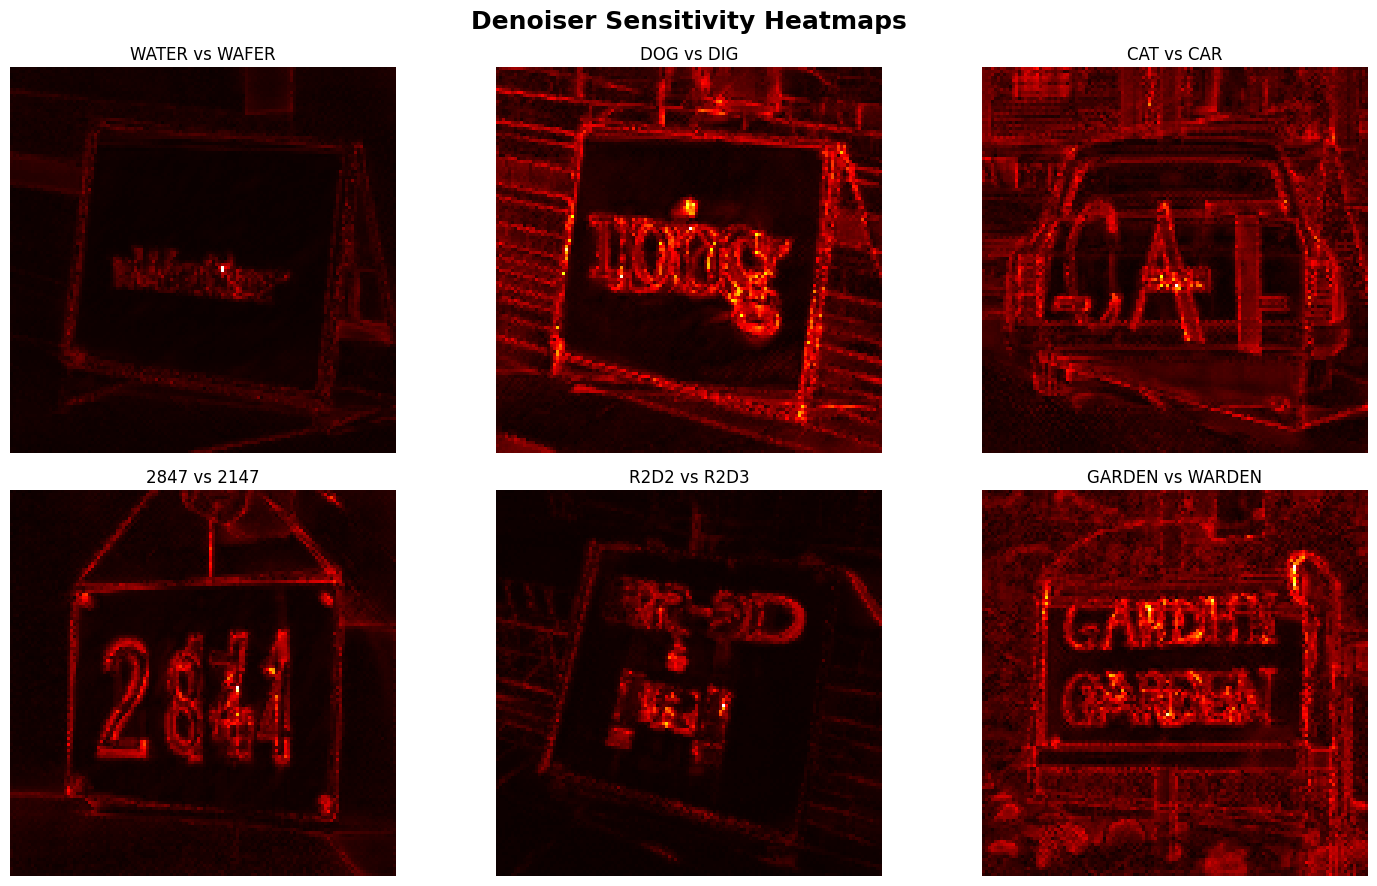

In [ ]:
pairs = [
    ('WATER', 'WAFER'),     # medium common
    ('DOG', 'DIG'),         # short common
    ('CAT', 'CAR'),         # short common
    ('2847', '2147'),       # digits
    ('R2D2', 'R2D3'),       # mixed
    ('GARDEN', 'WARDEN'),   # medium common
]

template = 'a plain white sign with the word "{}" printed clearly on it'
seed = 42

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ax, (word_a, word_b) in zip(axes.flat, pairs):
    prompt_a = template.format(word_a)
    prompt_b = template.format(word_b)

    noise_a = get_noise_pred(pipe, prompt_a, seed)
    noise_b = get_noise_pred(pipe, prompt_b, seed)

    diff = (noise_a - noise_b).squeeze(0)
    l2_map = diff.pow(2).sum(dim=0).sqrt()

    ax.imshow(l2_map.numpy(), cmap='hot')
    ax.set_title(f'{word_a} vs {word_b}')
    ax.axis('off')

plt.suptitle('Denoiser Sensitivity Heatmaps', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'results' / 'exp1_3_heatmap_grid.png', dpi=150, bbox_inches='tight')
plt.show()

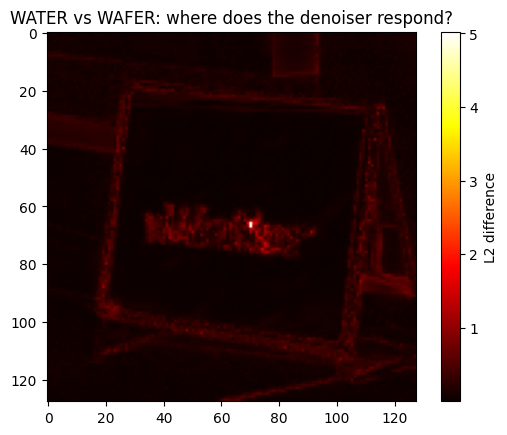

In [ ]:
plt.imshow(l2_map.numpy(), cmap='hot')
plt.colorbar(label='L2 difference')
plt.title('WATER vs WAFER: where does the denoiser respond?')
plt.savefig(OUTPUT_DIR / 'results' / 'exp1_3_l2_heatmap.png', dpi=150)
plt.show()

  0%|          | 0/50 [00:00<?, ?it/s]

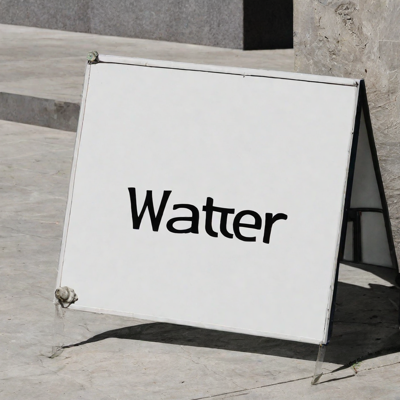

In [ ]:
g = torch.Generator(device='cpu').manual_seed(42)
img = pipe(prompt_a, generator=g, **GEN_KWARGS).images[0]
display(img.resize((400, 400)))

#2. Cross-Attention Misbinding  

###2.1 Attention Capture

In [ ]:
import math
import torch.nn.functional as F
from diffusers.models.attention_processor import Attention
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Tuple


# ── Captured data structures ─────────────────────────────────────────────

@dataclass
class AttentionSnapshot:
    """One cross-attention tensor captured for one layer at one timestep."""
    layer_name: str
    timestep:   int
    # (1, heads, n_spatial, n_text): batch-dim kept for API consistency
    weights:    torch.Tensor   # CPU float32
    spatial_hw: Tuple[int, int]


@dataclass
class GenerationRecord:
    prompt:        str
    generation_id: int
    snapshots:     List[AttentionSnapshot] = field(default_factory=list)
    ocr_success:   Optional[bool]  = None
    lev_distance:  Optional[float] = None
    image:         Optional[object] = None


# ── Custom attention processor ────────────────────────────────────────────

class CapturingAttnProcessor:
    """
    Drop-in replacement for AttnProcessor2_0 that:
    1. Runs standard scaled-dot-product attention (CPU-compatible, no xformers).
    2. Stores the softmax weights into a shared store at target timesteps.
    Only fires on cross-attention (encoder_hidden_states present).
    """
    def __init__(self, layer_name: str, store: dict, current_t_ref: list):
        self.layer_name    = layer_name
        self.store         = store        # mutated in-place: {layer_name: {t: Tensor}}
        self.current_t_ref = current_t_ref  # [t_value] — single-element list as mutable ref

    def __call__(
        self,
        attn: Attention,
        hidden_states: torch.Tensor,
        encoder_hidden_states: Optional[torch.Tensor] = None,
        attention_mask: Optional[torch.Tensor] = None,
        **kwargs,
    ) -> torch.Tensor:
        if encoder_hidden_states is None:
            # Self-attention — skip capture, run normally
            return AttnProcessor2_0()(attn, hidden_states, attention_mask=attention_mask)

        B, N, _ = hidden_states.shape
        q = attn.to_q(hidden_states)          # (B, N, inner_dim)
        k = attn.to_k(encoder_hidden_states)
        v = attn.to_v(encoder_hidden_states)

        # Reshape to multi-head: (B*H, tokens, head_dim)
        q = attn.head_to_batch_dim(q)
        k = attn.head_to_batch_dim(k)
        v = attn.head_to_batch_dim(v)

        scale = q.shape[-1] ** -0.5
        sim   = torch.bmm(q * scale, k.transpose(-1, -2))  # (B*H, N_s, N_t)

        if attention_mask is not None:
            sim = sim + attention_mask

        w = sim.softmax(dim=-1)               # (B*H, N_s, N_t)

        # ── Capture at target timesteps ──────────────────────────────────
        t = self.current_t_ref[0]
        if t in TARGET_TIMESTEPS:
            BH, N_s, N_t = w.shape
            H   = attn.heads
            hw  = int(N_s ** 0.5)
            w4d = w.view(B, H, N_s, N_t).detach().cpu().float()  # (B,H,N_s,N_t)
            self.store.setdefault(self.layer_name, {})[t] = w4d

        out = torch.bmm(w, v)                 # (B*H, N_s, head_dim)
        out = attn.batch_to_head_dim(out)     # (B, N_s, inner_dim)
        out = attn.to_out[0](out)
        out = attn.to_out[1](out)
        return out


# ── Hooker: swaps processors in/out ──────────────────────────────────────

class SDXLAttentionHooker:
    """
    Manages CapturingAttnProcessor installation on the SDXL U-Net.

    Usage
    -----
        hooker = SDXLAttentionHooker(pipe.unet)
        with hooker.recording(prompt='...', gen_id=0) as rec:
            image = pipe(**GEN_KWARGS, prompt=rec.prompt).images[0]
        rec.image = image
    """
    def __init__(self, unet):
        self.unet           = unet
        self._orig_procs    = {}   # layer_name = original processor
        self._store         = {}   # layer_name = {t: Tensor}
        self._current_t_ref = [None]   # mutable reference shared with processors
        self._record        = None

    def _target_layers(self):
        for name, mod in self.unet.named_modules():
            if not any(name.startswith(p) for p in CAPTURE_BLOCK_PREFIXES):
                continue
            if isinstance(mod, Attention):
                yield name, mod

    def set_timestep(self, t: int):
        self._current_t_ref[0] = int(t)

    def _install(self):
        self._store.clear()
        for name, mod in self._target_layers():
            self._orig_procs[name] = mod.processor
            mod.set_processor(
                CapturingAttnProcessor(name, self._store, self._current_t_ref)
            )

    def _uninstall(self):
        for name, mod in self._target_layers():
            if name in self._orig_procs:
                mod.set_processor(self._orig_procs[name])
        self._orig_procs.clear()

    def recording(self, prompt: str = '', gen_id: int = 0):
        import contextlib
        hooker = self

        @contextlib.contextmanager
        def _ctx():
            rec = GenerationRecord(prompt=prompt, generation_id=gen_id)
            hooker._record = rec
            hooker._install()
            try:
                yield rec
            finally:
                hooker._uninstall()
                for lname, t_dict in hooker._store.items():
                    for t, w in t_dict.items():
                        hw = int(w.shape[2] ** 0.5)
                        rec.snapshots.append(AttentionSnapshot(
                            layer_name=lname, timestep=t,
                            weights=w, spatial_hw=(hw, hw),
                        ))
                hooker._store.clear()
                hooker._record = None

        return _ctx()


hooker = SDXLAttentionHooker(pipe.unet)
print(f'Hooker ready. Watching '
      f'{sum(1 for _ in hooker._target_layers())} cross-attention layers.')

NameError: name 'CAPTURE_BLOCK_PREFIXES' is not defined

###2.2 OCR (TrOCR) and ROI Builder

In [ ]:
# ── OCR helpers ─────────────────────────────────────────────────────────

def trocr_read(image: Image.Image) -> str:
    """Run TrOCR on a PIL image, return raw recognised string."""
    pixel_values = trocr_processor(image, return_tensors='pt').pixel_values.to(device)
    with torch.no_grad():
        ids = trocr_model.generate(pixel_values)
    return trocr_processor.batch_decode(ids, skip_special_tokens=True)[0]


def ocr_score(image: Image.Image, target: str) -> float:
    """
    Normalised edit similarity ∈ [0, 1] between OCR output and target.
    1.0 = perfect match.
    """
    recognised = trocr_read(image).strip().upper()
    target_up  = target.strip().upper()
    max_len    = max(len(recognised), len(target_up), 1)
    return 1.0 - levenshtein_distance(recognised, target_up) / max_len


def ocr_succeeded(image: Image.Image, target: str, threshold: float = 0.7) -> bool:
    return ocr_score(image, target) >= threshold


# ── Bounding box ─────────────────────────────────────────────────────────

from dataclasses import dataclass as _dc

@_dc
class BoundingBox:
    """Normalised box in [0,1]×[0,1] image space."""
    x_min: float; y_min: float; x_max: float; y_max: float

    def to_spatial_mask(self, spatial_hw: Tuple[int,int]) -> np.ndarray:
        H, W = spatial_hw
        mask = np.zeros((H, W), dtype=bool)
        r0, r1 = int(self.y_min * H), int(self.y_max * H)
        c0, c1 = int(self.x_min * W), int(self.x_max * W)
        mask[r0:r1, c0:c1] = True
        return mask


# ── ROI builder ──────────────────────────────────────────────────────────

class ROITemplateBuilder:
    """
    Builds a stable spatial ROI from OCR-success images of complexity-0 prompts.

    Uses a sliding-window scan: divide the image into a grid of 8×8 tiles,
    score each tile with TrOCR, take the median bounding box of tiles whose
    score exceeds the threshold.

    Falls back to a centred 25-75% crop if too few success images collected.
    """
    GRID = 8  # tiles per side

    def __init__(self, n_success: int = 20, max_attempts: int = 60):
        self.n_success    = n_success
        self.max_attempts = max_attempts
        self._cache: Dict[str, BoundingBox] = {}

    def get_roi(self, target: str, _pipe, seeds=None) -> BoundingBox:
        if target in self._cache:
            return self._cache[target]

        # Always use the clean complexity-0 template
        template = COMPLEXITY_TEMPLATES[0][0]
        prompt   = template.format(text=target)

        if seeds is None:
            seeds = list(range(self.max_attempts))

        success_boxes: List[BoundingBox] = []
        for seed in seeds[:self.max_attempts]:
            if len(success_boxes) >= self.n_success:
                break
            g   = torch.Generator(device='cpu').manual_seed(seed)
            img = _pipe(prompt, generator=g, **GEN_KWARGS).images[0]

            if not ocr_succeeded(img, target, threshold=0.7):
                continue

            box = self._locate_text_box(img, target)
            if box is not None:
                success_boxes.append(box)

        if len(success_boxes) < 3:
            print(f'[ROI] Warning: only {len(success_boxes)} successes for "{target}"'
                  f' — using centred fallback')
            roi = BoundingBox(0.25, 0.25, 0.75, 0.75)
        else:
            arr = np.array([[b.x_min, b.y_min, b.x_max, b.y_max]
                            for b in success_boxes])
            med = np.median(arr, axis=0)
            roi = BoundingBox(*med)

        print(f'[ROI] "{target}" — {len(success_boxes)} images → '
              f'({roi.x_min:.2f},{roi.y_min:.2f})–({roi.x_max:.2f},{roi.y_max:.2f})')
        self._cache[target] = roi
        return roi

    def _locate_text_box(self, img: Image.Image, target: str) -> Optional[BoundingBox]:
        """Grid-scan: find the tile with highest OCR score for target."""
        W, H  = img.size
        G     = self.GRID
        tw, th = W // G, H // G

        best_score, best_box = 0.0, None
        for ri, ci in product(range(G), range(G)):
            x0, y0 = ci * tw, ri * th
            tile   = img.crop((x0, y0, x0 + tw, y0 + th))
            sc     = ocr_score(tile, target)
            if sc > best_score:
                best_score = sc
                best_box   = BoundingBox(
                    x0/W, y0/H, (x0+tw)/W, (y0+th)/H
                )
        return best_box if best_score > 0.4 else None


roi_builder = ROITemplateBuilder(n_success=20, max_attempts=60)
print('ROI builder ready.')

ROI builder ready.


###2.3 Attention Statistics

In [ ]:
@_dc
class LayerStats:
    layer_name: str; timestep: int
    roi_ratio: float; entropy: float
    centroid_x: float; centroid_y: float


@_dc
class GenerationStats:
    generation_id:  int
    prompt:         str
    ocr_success:    bool
    lev_score:      float
    per_layer:      Dict[Tuple[str,int], LayerStats]
    agg_roi_ratio:  Dict[int, float]   # timestep → mean over layers
    agg_entropy:    Dict[int, float]
    temporal_drift: Dict[int, float]   # centroid Δ between consecutive t


# ── Per-snapshot computations ─────────────────────────────────────────────

def _spatial_map(weights: np.ndarray,
                 token_indices: Optional[List[int]] = None) -> np.ndarray:
    """(B,H,N_s,N_t) → normalised (N_s,) attention-probability vector."""
    w = weights[0]           # drop batch dim → (H, N_s, N_t)
    if token_indices:
        w = w[:, :, token_indices]
    w = w.mean(0).sum(-1)    # avg heads, sum text tokens → (N_s,)
    tot = w.sum()
    return w / tot if tot > 1e-9 else w


def _to_hw(flat: np.ndarray, hw: Tuple[int,int]) -> np.ndarray:
    H, W = hw
    if flat.size == H * W:
        m = flat.reshape(H, W)
    else:  # non-square or mismatched → nearest-neighbour resize
        side = int(flat.size ** 0.5)
        tmp  = Image.fromarray((flat.reshape(side, side) * 255).astype(np.uint8))
        m    = np.array(tmp.resize((W, H), Image.NEAREST)).astype(np.float32) / 255
    tot = m.sum()
    return m / tot if tot > 1e-9 else m


def _roi_ratio(m: np.ndarray, mask: np.ndarray) -> float:
    return float(m[mask].sum())

def _entropy(m: np.ndarray) -> float:
    p = m.ravel(); p = p[p > 1e-12]
    return float(-np.sum(p * np.log(p)))

def _centroid(m: np.ndarray) -> Tuple[float, float]:
    H, W   = m.shape
    yy, xx = np.mgrid[0:H, 0:W] / np.array([H, W])[:, None, None]
    tot    = m.sum() + 1e-9
    return float((m * xx).sum() / tot), float((m * yy).sum() / tot)


# ── Main stats function ────────────────────────────────────────────────────

def compute_stats(
    rec: GenerationRecord,
    roi: BoundingBox,
    token_indices: Optional[List[int]] = None,
) -> GenerationStats:

    per_layer: Dict[Tuple[str,int], LayerStats] = {}
    cx_by_t: Dict[int, List[float]] = defaultdict(list)
    cy_by_t: Dict[int, List[float]] = defaultdict(list)

    for snap in rec.snapshots:
        hw    = snap.spatial_hw
        mask  = roi.to_spatial_mask(hw)
        flat  = _spatial_map(snap.weights.numpy(), token_indices)
        try:
            m = _to_hw(flat, hw)
        except Exception:
            continue

        cx, cy = _centroid(m)
        per_layer[(snap.layer_name, snap.timestep)] = LayerStats(
            layer_name=snap.layer_name, timestep=snap.timestep,
            roi_ratio=_roi_ratio(m, mask), entropy=_entropy(m),
            centroid_x=cx, centroid_y=cy,
        )
        cx_by_t[snap.timestep].append(cx)
        cy_by_t[snap.timestep].append(cy)

    # Aggregate over layers per timestep
    agg_roi = defaultdict(list); agg_ent = defaultdict(list)
    for (_, t), s in per_layer.items():
        agg_roi[t].append(s.roi_ratio); agg_ent[t].append(s.entropy)
    agg_roi = {t: float(np.mean(v)) for t, v in agg_roi.items()}
    agg_ent = {t: float(np.mean(v)) for t, v in agg_ent.items()}
    agg_cx  = {t: float(np.mean(v)) for t, v in cx_by_t.items()}
    agg_cy  = {t: float(np.mean(v)) for t, v in cy_by_t.items()}

    # Temporal drift: centroid Euclidean distance between consecutive t
    drift: Dict[int, float] = {}
    prev = None
    for t in TIMESTEPS_ORDERED:
        if t not in agg_cx: continue
        if prev is None:
            drift[t] = 0.0
        else:
            drift[t] = float(np.hypot(agg_cx[t]-agg_cx.get(prev, agg_cx[t]),
                                      agg_cy[t]-agg_cy.get(prev, agg_cy[t])))
        prev = t

    return GenerationStats(
        generation_id=rec.generation_id, prompt=rec.prompt,
        ocr_success=bool(rec.ocr_success),
        lev_score=float(rec.lev_distance or 0.0),
        per_layer=per_layer, agg_roi_ratio=agg_roi,
        agg_entropy=agg_ent, temporal_drift=drift,
    )


# ── Group-level summary (mean with SE) ───────────────────────────────────────

def group_stats(stat_list: List[GenerationStats]) -> Dict[str, Dict[int, Tuple[float,float]]]:
    """Returns {metric_outcome: {t: (mean, se)}} for each metric × outcome combo."""
    def _vals(group, attr, t):
        return [getattr(s, attr).get(t, np.nan) for s in group
                if not np.isnan(getattr(s, attr).get(t, np.nan))]

    def _ms(vals):
        if not vals: return (np.nan, np.nan)
        a = np.array(vals)
        return float(a.mean()), float(a.std() / (len(a)**0.5 + 1e-9))

    suc = [s for s in stat_list if s.ocr_success]
    fai = [s for s in stat_list if not s.ocr_success]
    out = {}
    for pfx, grp in [('success', suc), ('failure', fai)]:
        for metric in ('agg_roi_ratio', 'agg_entropy', 'temporal_drift'):
            key = f'{pfx}_{metric.replace("agg_","")}'
            out[key] = {t: _ms(_vals(grp, metric, t)) for t in TIMESTEPS_ORDERED}
    return out


print('Stats helpers defined.')

###2.4 Ablation Runner

In [ ]:
def _make_scheduler_patch(hooker, original_step):
    """Returns a patched scheduler.step that notifies the hooker."""
    def patched_step(model_output, timestep, sample, *a, **kw):
        hooker.set_timestep(int(timestep.item()
                               if hasattr(timestep, 'item') else timestep))
        return original_step(model_output, timestep, sample, *a, **kw)
    return patched_step


def run_ablation(
    target_strings: List[str] = TARGET_STRINGS,
    n_per_cell:     int        = 30,
    resume:         bool       = True,   # skip cells whose JSON already exists
) -> Dict[str, List[GenerationStats]]:

    all_results: Dict[str, List[GenerationStats]] = {}
    gen_id = 0

    for complexity in sorted(COMPLEXITY_TEMPLATES):
        templates = COMPLEXITY_TEMPLATES[complexity]
        for target in target_strings:
            cell_key  = f'c{complexity}_{target}'
            save_path = OUT_DIR / 'ablation' / f'{cell_key}.json'

            # ── Resume: reload saved cell ──────────────────────────────
            if resume and save_path.exists():
                all_results[cell_key] = _load_cell(save_path)
                print(f'[Resume] {cell_key} — {len(all_results[cell_key])} records loaded')
                continue

            # ── Build ROI from clean template ─────────────────────────
            roi = roi_builder.get_roi(target, pipe)

            cell_stats: List[GenerationStats] = []
            print(f'\n[Cell] {cell_key}  complexity={COMPLEXITY_NAMES[complexity]}')

            for i in range(n_per_cell):
                seed   = (hash((cell_key, i)) & 0xFFFFFFFF)
                tmpl   = templates[i % len(templates)]
                prompt = tmpl.format(text=target)
                g      = torch.Generator(device='cpu').manual_seed(seed)

                # Patch scheduler for this generation only
                orig_step             = pipe.scheduler.step
                pipe.scheduler.step  = _make_scheduler_patch(hooker, orig_step)

                with hooker.recording(prompt=prompt, gen_id=gen_id) as rec:
                    image       = pipe(prompt, generator=g, **GEN_KWARGS).images[0]
                    rec.image   = image
                    score       = ocr_score(image, target)
                    rec.lev_distance = score
                    rec.ocr_success  = score >= 0.7

                pipe.scheduler.step = orig_step   # always restore

                gs = compute_stats(rec, roi)
                cell_stats.append(gs)
                gen_id += 1

                mark = '✓' if rec.ocr_success else '✗'
                print(f'  [{mark}] {i+1:3d}/{n_per_cell}  '
                      f'lev={score:.2f}  '
                      f'roi@700={gs.agg_roi_ratio.get(700, float("nan")):.3f}')

            all_results[cell_key] = cell_stats
            _save_cell(cell_stats, save_path)

    return all_results


# ── JSON serialisation helpers ────────────────────────────────────────────

def _save_cell(stats: List[GenerationStats], path: Path):
    data = []
    for s in stats:
        data.append({
            'generation_id': s.generation_id, 'prompt': s.prompt,
            'ocr_success': s.ocr_success, 'lev_score': s.lev_score,
            'agg_roi_ratio':  {str(k): v for k, v in s.agg_roi_ratio.items()},
            'agg_entropy':    {str(k): v for k, v in s.agg_entropy.items()},
            'temporal_drift': {str(k): v for k, v in s.temporal_drift.items()},
        })
    with open(path, 'w') as f:
        json.dump(data, f, indent=2)
    print(f'  [Saved] {path}')


def _load_cell(path: Path) -> List[GenerationStats]:
    with open(path) as f:
        data = json.load(f)
    out = []
    for d in data:
        out.append(GenerationStats(
            generation_id  = d['generation_id'],
            prompt         = d.get('prompt', ''),
            ocr_success    = d['ocr_success'],
            lev_score      = d.get('lev_score', 0.0),
            per_layer      = {},   # not persisted
            agg_roi_ratio  = {int(k): v for k, v in d['agg_roi_ratio'].items()},
            agg_entropy    = {int(k): v for k, v in d['agg_entropy'].items()},
            temporal_drift = {int(k): v for k, v in d['temporal_drift'].items()},
        ))
    return out


print('Ablation runner defined.')

###2.5 Plots!

In [ ]:
ALPHA_BAND = 0.15
LS = {'success': '-', 'failure': '--'}


def _plot_metric_curves(ax, by_complexity, metric_key, ylabel, title):
    """Shared helper: draw curves for one metric across all complexities."""
    for c, stats_list in by_complexity.items():
        g   = group_stats(stats_list)
        col = COMPLEXITY_COLORS[c]
        lbl = COMPLEXITY_NAMES[c]
        for outcome in ('success', 'failure'):
            key = f'{outcome}_{metric_key}'
            ts  = [t for t in TIMESTEPS_ORDERED if not np.isnan(g[key][t][0])]
            mn  = [g[key][t][0] for t in ts]
            se  = [g[key][t][1] for t in ts]
            ax.plot(ts, mn, color=col, ls=LS[outcome],
                    lw=2, marker='o', ms=5)
            ax.fill_between(ts,
                [m-s for m,s in zip(mn,se)], [m+s for m,s in zip(mn,se)],
                color=col, alpha=ALPHA_BAND)
    ax.set_xlabel('Denoising timestep t', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.set_xticks(TIMESTEPS_ORDERED)
    ax.set_xlim(950, 50)   # reversed: coarse→fine
    ax.axvline(700, color='gray', ls=':', lw=1, alpha=0.6)
    ax.grid(True, alpha=0.3)


def _complexity_by(all_results):
    by_c = {0: [], 1: [], 2: []}
    for k, v in all_results.items():
        by_c[int(k[1])].extend(v)
    return by_c


def _legend_handles():
    import matplotlib.patches as mpatches
    import matplotlib.lines as mlines
    patches = [mpatches.Patch(color=COMPLEXITY_COLORS[c], label=COMPLEXITY_NAMES[c])
               for c in [0, 1, 2]]
    lines   = [mlines.Line2D([], [], color='gray', ls='-',  label='OCR success'),
               mlines.Line2D([], [], color='gray', ls='--', label='OCR failure')]
    return patches + lines


# ── Plot 1: ROI ratio vs timestep ─────────────────────────────────────────

def plot_roi_vs_timestep(all_results, save=True):
    fig, ax = plt.subplots(figsize=(8, 5))
    _plot_metric_curves(ax, _complexity_by(all_results),
                        'roi_ratio', 'Attention-to-ROI ratio',
                        'Attention convergence to text ROI by scene complexity')
    ax.set_ylim(0, 1)
    ax.legend(handles=_legend_handles(), fontsize=9, loc='lower right')
    plt.tight_layout()
    if save: plt.savefig(OUT_DIR / 'roi_vs_timestep.pdf', dpi=150, bbox_inches='tight')
    plt.show()


# ── Plot 2: Entropy + drift panels ────────────────────────────────────────

def plot_entropy_drift(all_results, save=True):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
    by_c = _complexity_by(all_results)
    _plot_metric_curves(ax1, by_c, 'entropy',
                        'Entropy (nats)', 'Attention entropy vs timestep')
    _plot_metric_curves(ax2, by_c, 'temporal_drift',
                        'Centroid drift (norm.)', 'Centroid temporal drift')
    ax2.legend(handles=_legend_handles(), fontsize=9, loc='upper right')
    plt.tight_layout()
    if save: plt.savefig(OUT_DIR / 'entropy_drift.pdf', dpi=150, bbox_inches='tight')
    plt.show()


# ── Plot 3: Per-string heatmap of success−failure gap at t=700 ────────────

def plot_success_gap_heatmap(all_results, save=True):
    strings = TARGET_STRINGS
    comps   = [0, 1, 2]
    mat     = np.full((len(strings), len(comps)), np.nan)

    for ci, c in enumerate(comps):
        for si, s in enumerate(strings):
            key = f'c{c}_{s}'
            if key not in all_results: continue
            g = group_stats(all_results[key])
            suc = g['success_roi_ratio'].get(700, (np.nan,))[0]
            fai = g['failure_roi_ratio'].get(700, (np.nan,))[0]
            mat[si, ci] = suc - fai

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(mat, vmin=-0.3, vmax=0.3, cmap='RdYlGn', aspect='auto')
    ax.set_xticks(range(len(comps)))
    ax.set_xticklabels([COMPLEXITY_NAMES[c] for c in comps], fontsize=11)
    ax.set_yticks(range(len(strings)))
    ax.set_yticklabels(strings, fontsize=11)
    ax.set_title('ROI-ratio gap (success − failure) at t=700', fontsize=11)
    for si in range(len(strings)):
        for ci in range(len(comps)):
            v = mat[si, ci]
            if not np.isnan(v):
                ax.text(ci, si, f'{v:.2f}', ha='center', va='center', fontsize=10)
    plt.colorbar(im, ax=ax, label='Δ ROI ratio')
    plt.tight_layout()
    if save: plt.savefig(OUT_DIR / 'gap_heatmap.pdf', dpi=150, bbox_inches='tight')
    plt.show()


# ── Analysis helpers ──────────────────────────────────────────────────────

def print_significance_table(all_results):
    from scipy.stats import mannwhitneyu
    print(f'\n{"Cell":20s}  {"n_suc":>6}  {"n_fai":>6}  {"U":>8}  {"p":>8}  {"r":>6}')
    print('-' * 60)
    for key, sl in sorted(all_results.items()):
        sv = [s.agg_roi_ratio.get(700, np.nan) for s in sl if s.ocr_success]
        fv = [s.agg_roi_ratio.get(700, np.nan) for s in sl if not s.ocr_success]
        sv = [v for v in sv if not np.isnan(v)]
        fv = [v for v in fv if not np.isnan(v)]
        if len(sv) < 2 or len(fv) < 2:
            print(f'{key:20s}  {len(sv):6d}  {len(fv):6d}  (insufficient data)')
            continue
        U, p = mannwhitneyu(sv, fv, alternative='greater')
        r    = 1 - 2*U / (len(sv)*len(fv))
        print(f'{key:20s}  {len(sv):6d}  {len(fv):6d}  {U:8.1f}  {p:8.4f}  {r:6.3f}')


def convergence_table(all_results):
    print(f'\n{"Cell":20s}  {"conv_t":>8}  {"suc_rate":>10}')
    print('-' * 44)
    for key, sl in sorted(all_results.items()):
        g = group_stats(sl)
        thresh_t = None
        for t in TIMESTEPS_ORDERED:
            if g['success_roi_ratio'][t][0] >= 0.5:
                thresh_t = t; break
        rate = sum(s.ocr_success for s in sl) / max(len(sl), 1)
        print(f'{key:20s}  {str(thresh_t) if thresh_t else ">100":>8}  {rate:>10.2f}')


print('Plotting helpers defined.')

In [ ]:
N_PER_CELL = 10   # ← increase to 30 on A100

all_results = run_ablation(
    target_strings = TARGET_STRINGS,
    n_per_cell     = N_PER_CELL,
    resume         = True,   # skips cells whose JSON is already saved
)

In [ ]:
plot_roi_vs_timestep(all_results)
plot_entropy_drift(all_results)
plot_success_gap_heatmap(all_results)
print_significance_table(all_results)
convergence_table(all_results)